<a href="https://colab.research.google.com/github/BahruzHuseynov/Portfolio/blob/main/PyTorch_Layers_Practice.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import requests
from PIL import Image
import matplotlib.pyplot as plt
from io import BytesIO
import numpy as np

import torch
from torch import nn
from torchvision import transforms

In [3]:
url = "https://encrypted-tbn0.gstatic.com/images?q=tbn:ANd9GcTsyea3SNPMzb-aMyTNf0L1psfBzirvm4fFObSPQOXirg&s"
response = requests.get(url)

if response.status_code == 200:
    image = Image.open(BytesIO(response.content))
    image.show()
else:
    print("Failed to retrieve the image. Status code:", response.status_code)

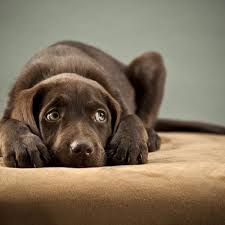

In [4]:
image

In [5]:
transform = transforms.ToTensor()
img = transform(image)

In [6]:
img.shape

torch.Size([3, 225, 225])

### Convolution and Pooling formulas

<img src = "https://i.sstatic.net/DaVvL.png">

In [7]:
i = Image.open("Conv_Pooling_Formula.png")
i

FileNotFoundError: [Errno 2] No such file or directory: 'Conv_Pooling_Formula.png'

### Convolution

In [ ]:
conv_ex = nn.Conv2d(in_channels=3, out_channels = 1, kernel_size = 7, stride = 1, padding = 1) # dilation = 1 (default)
conv_res = conv_ex(img)
conv_res.shape

*   H_in = 225
*   H_out = (225 + 2 * 1 - 7)/1 + 1 = 221

In [ ]:
conv_res = conv_res.permute(1,2,0) # shape --> 221, 221, 1
plt.imshow(conv_res.detach().numpy())

### Max Pooling

In [ ]:
mx_pool_ex = nn.MaxPool2d(kernel_size = 5, stride = 1, padding = 0)
mx_pool_res = mx_pool_ex(img)
mx_pool_res.shape

In [ ]:
mx_pool_res = mx_pool_res.permute(1,2,0) # shape --> 221, 221, 1
plt.imshow(mx_pool_res.detach().numpy())

### Average Pooling

In [ ]:
avg_pool_ex = nn.AvgPool2d(kernel_size = 5, stride = 1, padding = 0)
avg_pool_res = avg_pool_ex(img)
avg_pool_res.shape

In [ ]:
avg_pool_res = avg_pool_res.permute(1,2,0) # shape --> 221, 221, 1
plt.imshow(avg_pool_res.detach().numpy())

### Flatten

In [ ]:
flattened_img = img.flatten()
flattened_img

In [ ]:
flattened_img.shape  # shape = 225 * 225,

### Activation Functions

<img src = "https://iq.opengenus.org/content/images/2021/11/Comparion-of-Activation-Functions--1-.png">

In [ ]:
af_sigmoid = nn.Sigmoid()
af_sigmoid(img)

In [ ]:
print("X: ", img[0,0,0])
print("Y: ", af_sigmoid(img)[0,0,0])
print("Our calculation: ", 1 / (1 + np.exp(-img[0,0,0])))

### Depthwise Convolution

### Pointwise Convolution

### Transposed convolution (or Deconvolution)

<img src = "https://miro.medium.com/v2/resize:fit:1400/1*uk4KJEtyDuPOipfG4yd-WA.gif" width = '600'>

In the example above, transposed convolution is applied with these parameters:
- padding = 2
- stride = 1
- kernel_size = 3

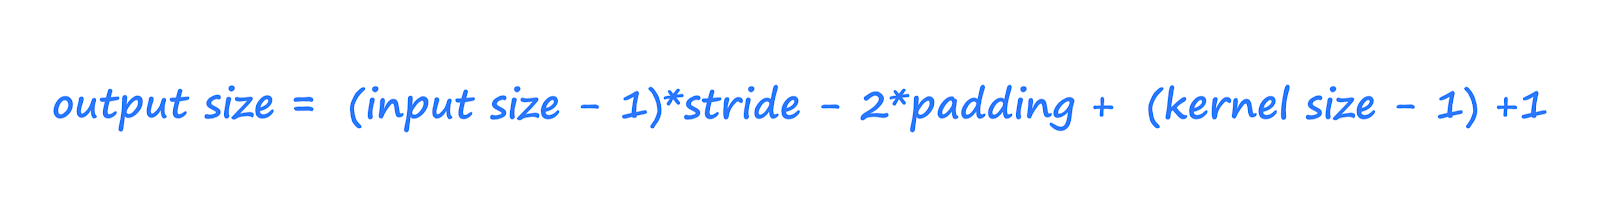

In [8]:
deconv_ex = nn.ConvTranspose2d(in_channels = 3, out_channels = 3, kernel_size = 5, stride = 1, padding = 1)
deconv_res = deconv_ex(img)
deconv_res.shape

torch.Size([3, 227, 227])

- H_in = 225
- H_out = (225 - 1) * 1 - 2 * 1 + (5 - 1) + 1 = 227

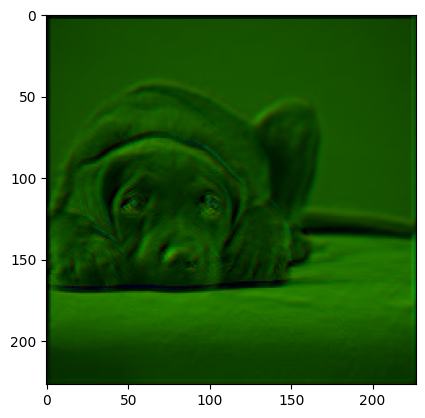

In [9]:
deconv_res = deconv_res.permute(1,2,0) # shape --> 227, 227, 3
plt.imshow(deconv_res.detach().numpy())

### Unpooling

<img src = "https://mriquestions.com/uploads/3/4/5/7/34572113/uppooling-methods_orig.png">

- No any Bed of Nails and Nearest Neighbor class or method to apply directly from PyTorch
- But they can be customly built constructed and used in the custom models

In [76]:
max_unpool_ex = nn.MaxUnpool2d(kernel_size = 2, stride=2)
max_unpool_res = max_unpool_ex(img)
max_unpool_res.shape

TypeError: MaxUnpool2d.forward() missing 1 required positional argument: 'indices'

### Concatination

In [10]:
a = torch.randn(10, 20, 5, 5)
b = torch.randn(10, 20, 5, 5)

In [11]:
print("Dim 0 -->", torch.cat((a, b), dim = 0).shape)
print("Dim 1 -->", torch.cat((a, b), dim = 1).shape)
print("Dim 2 -->", torch.cat((a, b), dim = 2).shape)
print("Dim 3 -->", torch.cat((a, b), dim = 3).shape)

Dim 0 --> torch.Size([20, 20, 5, 5])
Dim 1 --> torch.Size([10, 40, 5, 5])
Dim 2 --> torch.Size([10, 20, 10, 5])
Dim 3 --> torch.Size([10, 20, 5, 10])


- Input Tensor --> (batch_size, seq_length, input_size)
- RNN Cell --> (input_size, hidden_size)
- Hidden state must be in this shape: (batch_size, hidden_size)
- Input step must be in this shape: (batch_size, input_size) representing each tokenized element of the sequence
- Outputs --> (batch_size, seq_length, hidden_size)

<br>

Depending on the situation, the input tensor can have this structure: (batch_size, seq_length, input_size). In this situation, there must be some modifications in the coding parts

### RNN Cell, GRU Cell and LSTM Cell

In [37]:
def function(input_size, hidden_size, batch_size, seq_length):
    # cell = nn.GRUCell(input_size, hidden_size)
    # Same results with GRUCell, but various calculations at the back
    cell = nn.RNNCell(input_size, hidden_size)

    input_data = torch.randn(batch_size, seq_length, input_size)

    # Initialize the hidden state
    h_0 = torch.zeros(batch_size, hidden_size)

    outputs = []
    for i in range(seq_length):
        input_step = input_data[:, i, :]  # (batch_size, input_size)
        h_0 = cell(input_step, h_0)  # (batch_size, hidden_size)
        outputs.append(h_0.unsqueeze(1))
        # In each loop (batch_size, 1, hidden_size) is added to the output
        # Then, based on the dimension 1 (seq_length), they are concatenated

    outputs = torch.cat(outputs, dim=1) # (batch_size, seq_length, hidden_size)
    return outputs

In [39]:
input_size = 2
hidden_size = 5
batch_size = 4
seq_length = 10

In [40]:
rnn_outputs = function(input_size, hidden_size, batch_size, seq_length)
rnn_outputs.shape

torch.Size([4, 10, 5])

In [50]:
lstm_cell = nn.LSTMCell(input_size, hidden_size)
input_data = torch.randn(batch_size, seq_length, input_size)
h_0 = torch.zeros(batch_size, hidden_size)
c_0 = torch.zeros(batch_size, hidden_size)

outputs = []
for i in range(seq_length):
    input_step = input_data[:, i, :]  # (batch_size, input_size)
    h_0, c_0 = lstm_cell(input_step, (h_0, c_0))  # (batch_size, hidden_size)
    outputs.append(h_0.unsqueeze(1))

outputs = torch.cat(outputs, dim=1) # (batch_size, seq_length, hidden_size)
print("Output sequence shape:", outputs.shape)

Output sequence shape: torch.Size([4, 10, 5])


### RNN, GRU and LSTM Layers

- Input Tensor --> (batch_size, seq_length, input_size)

- Output Tensor --> (batch_size, seq_len, num_dir * hidden_size)
- Hidden State Tensor --> (batch_size, num_layers * num_directions, hidden_size)

In [51]:
input_size = 2
hidden_size = 5
batch_size = 4
seq_length = 10

input_data = torch.randn(batch_size, seq_length, input_size)

# RNN
rnn_layer = nn.RNN(input_size, hidden_size, num_layers = 1, batch_first = True)
out, h_n = rnn_layer(input_data)

In [59]:
out.shape, h_n.shape

(torch.Size([4, 10, 5]), torch.Size([1, 4, 5]))

In [60]:
# GRU Layer
gru_layer = nn.GRU(input_size, hidden_size, num_layers = 1, batch_first = True)
out, h_n = gru_layer(input_data)

In [61]:
out.shape, h_n.shape

(torch.Size([4, 10, 5]), torch.Size([1, 4, 5]))

In [63]:
# LSTM Layer
lstm_layer = nn.LSTM(input_size, hidden_size, num_layers = 1, batch_first = True)
out, (h_n, c_n) = lstm_layer(input_data)

In [64]:
out.shape, h_n.shape, c_n.shape

(torch.Size([4, 10, 5]), torch.Size([1, 4, 5]), torch.Size([1, 4, 5]))